# Data Science Cohort 7
**Name:** Gideon Monday Silas

## Project: Task 3 - Pizza Place Sales Analysis
In this project, I imported the necessary tools, loaded my four CSV files, and combined them into one unified table before the analysis starts.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Loading of the datasets


### 1st Dataset

In [4]:
order_details = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\order_details.csv")

order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


### 2nd Dataset

In [6]:
orders = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\orders.csv")

orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


### 3rd Dataset

In [8]:
pizzas = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\pizzas.csv")

pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


### 4th Dataset

In [10]:
pizza_types = pd.read_csv(r"C:\Users\USER\Downloads\Pizza+Place+Sales\pizza_sales\pizza_types.csv", encoding="ISO-8859-1")

pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


## Joining the four CSV files into a single data frame

In [12]:
df = order_details.merge(orders, on='order_id')
df = df.merge(pizzas, on='pizza_id')
df = df.merge(pizza_types, on='pizza_type_id')

print("Data successfully merged.")

Data successfully merged.


In [13]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [14]:
df.shape

(48620, 12)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   pizza_id          48620 non-null  object 
 3   quantity          48620 non-null  int64  
 4   date              48620 non-null  object 
 5   time              48620 non-null  object 
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [16]:
# Convert date and time columns to proper formats for later analysis

df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.strftime('%m-%B')

print("Date and time columns successfully converted properly.")

Date and time columns successfully converted properly.


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   pizza_id          48620 non-null  object        
 3   quantity          48620 non-null  int64         
 4   date              48620 non-null  datetime64[ns]
 5   time              48620 non-null  object        
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
 12  hour              48620 non-null  int32         
 13  day_of_week       48620 non-null  object        
 14  month             4862

In [18]:
df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,hour,day_of_week,month
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",11,Thursday,01-January
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",11,Thursday,01-January
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",11,Thursday,01-January
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",11,Thursday,01-January
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",11,Thursday,01-January


# Finding the revenue 
(quantity * price)

In [20]:
df['revenue'] = df['quantity'] * df['price']

df['revenue']

0        13.25
1        16.00
2        18.50
3        20.75
4        16.00
         ...  
48615    16.75
48616    17.95
48617    12.00
48618    20.25
48619    12.75
Name: revenue, Length: 48620, dtype: float64

# Calculating the Overall Totals

In [22]:
# 1. What is the total revenue/sales?

total_revenue = df['revenue'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $817,860.05


In [23]:
# 2. Find the total quantity sold.

total_quantity = df['quantity'].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 49,574


In [24]:
# 3. Find the total orders.

total_orders = df['order_id'].nunique()
print(f"Total Orders: {total_orders:,}")

Total Orders: 21,350


In [25]:
# 4. How many pizza types do they sell?

num_pizza_types = df['pizza_type_id'].nunique()
print(f"Total Pizza Types: {num_pizza_types}")

Total Pizza Types: 32


In [26]:
# 5. Find the average price of the pizzas.

avg_price = pizzas['price'].mean()
print(f"Average Pizza Price: ${avg_price:.2f}")

Average Pizza Price: $16.44


# Peak Hours Analysis

In [28]:
# 6. What are the peak hours of sales?

peak_hours = df.groupby('hour')['order_id'].nunique().sort_values(ascending=False)
print("Peak Hours (Top 5):")
print(peak_hours.head())

Peak Hours (Top 5):
hour
12    2520
13    2455
18    2399
17    2336
19    2009
Name: order_id, dtype: int64


## Line Plotting

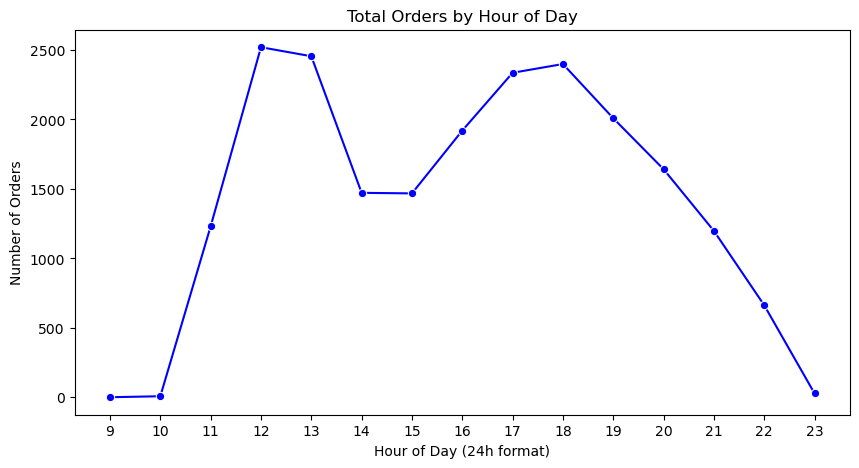

In [30]:
# Creating dataset

hourly_orders = df.groupby('hour')['order_id'].nunique().reset_index()
plt.figure(figsize=(10, 5))

#line plot
sns.lineplot(data=hourly_orders, x='hour', y='order_id', marker='o', color='blue')

plt.title('Total Orders by Hour of Day')
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('Number of Orders')
plt.xticks(range(9, 24))

plt.show()

### Insight:
The peak hours of sales are 12:00 PM and 1:00 PM for the lunch rush, followed closely by 5:00 PM and 6:00 PM for the dinner rush.

# Daily Sales Analysis

In [33]:
# 7. Find the total sales made on each day of the week. Which day is most?

day_sales = df.groupby('day_of_week')['revenue'].sum().sort_values(ascending=False)
print("Total Sales by Day of the Week:")
print(day_sales)

Total Sales by Day of the Week:
day_of_week
Friday       136073.90
Thursday     123528.50
Saturday     123182.40
Wednesday    114408.40
Tuesday      114133.80
Monday       107329.55
Sunday        99203.50
Name: revenue, dtype: float64


## Bar Plotting

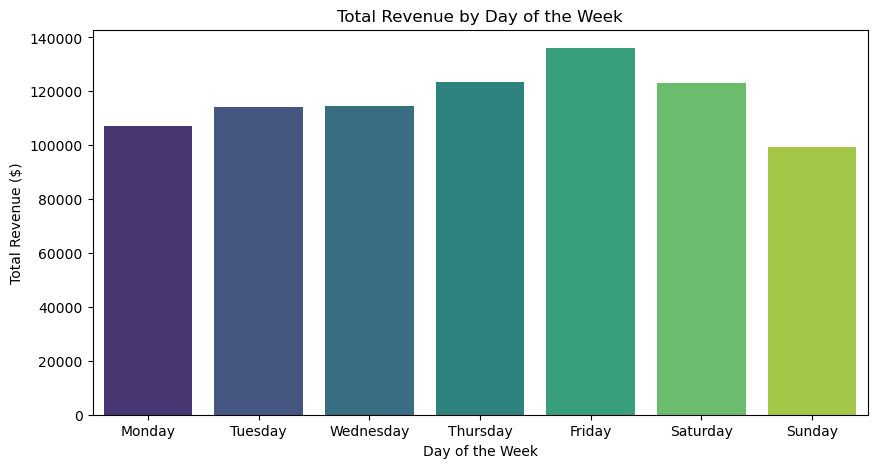

In [35]:
#Creating dataset

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = df.groupby('day_of_week')['revenue'].sum().reindex(days_order).reset_index()
plt.figure(figsize=(10, 5))

#Barplot
sns.barplot(data=day_revenue, x='day_of_week', y='revenue', palette='viridis')
plt.title('Total Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue ($)')

plt.show()

### Insight:
Friday is the day when most sales are made, bringing in $136,073.90. Sales steadily increase throughout the week, peak on Friday, and drop to their lowest point on Sunday.

# Bestselling Pizzas

In [38]:
# 8. Find the top 5 bestselling pizzas.

top_5_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(5)
print("Top 5 Bestselling Pizzas:")
print(top_5_pizzas)

Top 5 Bestselling Pizzas:
name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64


## Bar Plotting

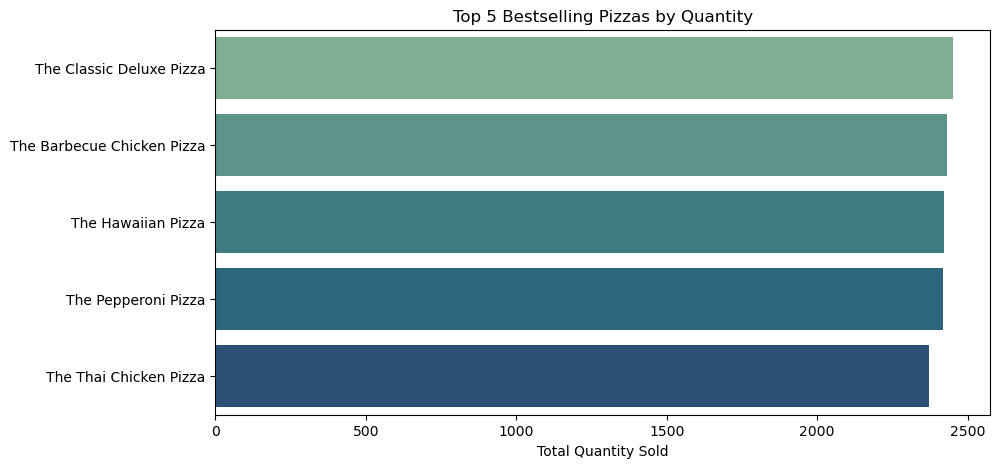

In [40]:
top_5_df = top_5_pizzas.reset_index()
plt.figure(figsize=(10, 5))

#Barplot
sns.barplot(data=top_5_df, y='name', x='quantity', palette='crest')
plt.title('Top 5 Bestselling Pizzas by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('')

plt.show()

### Insight: 
The Classic Deluxe Pizza is the most popular item on the menu, closely followed by The Barbecue Chicken Pizza and The Hawaiian Pizza.

# Monthly Sales Trend

In [43]:
# 9. Find the sales made in each month. Any trend noticeable?

monthly_sales = df.groupby('month')['revenue'].sum()
print("Sales Made in Each Month:")
print(monthly_sales)

Sales Made in Each Month:
month
01-January      69793.30
02-February     65159.60
03-March        70397.10
04-April        68736.80
05-May          71402.75
06-June         68230.20
07-July         72557.90
08-August       68278.25
09-September    64180.05
10-October      64027.60
11-November     70395.35
12-December     64701.15
Name: revenue, dtype: float64


## Line Plotting

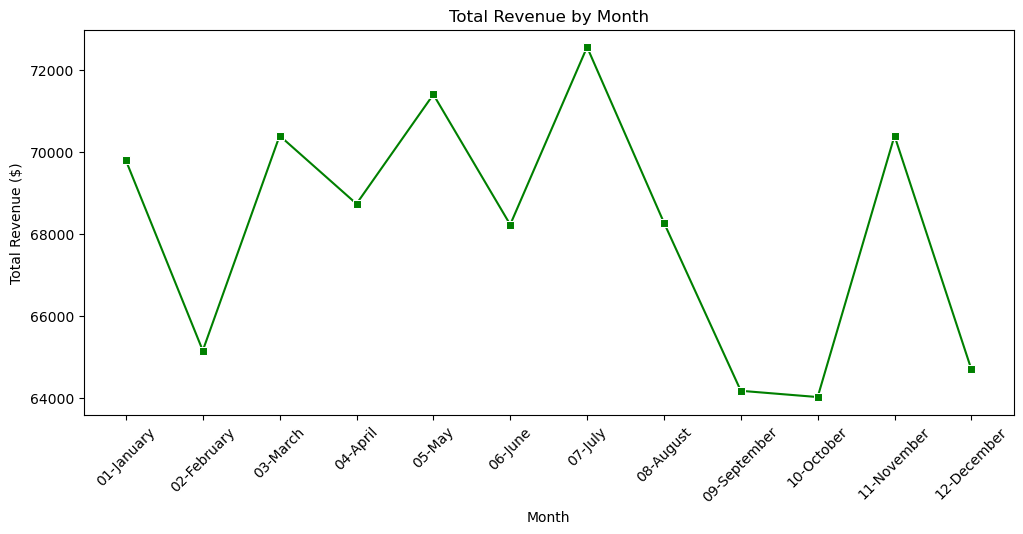

In [45]:
monthly_sales_df = monthly_sales.reset_index()
plt.figure(figsize=(12, 5))

#Lineplot
sns.lineplot(data=monthly_sales_df, x='month', y='revenue', marker='s', color='green')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)

plt.show()

### Insight: 
Sales are relatively stable throughout the year, hovering between 64,000 and 72,000 per month. July is the strongest performing month, while September and October show a slight dip in revenue.

# Underperforming Pizzas

In [48]:
# 10. Are there pizza types that are not doing well on the menu?

bottom_pizzas = df.groupby('name')['quantity'].sum().sort_values(ascending=True).head(5)
print("Bottom 5 Underperforming Pizzas:")
print(bottom_pizzas)

Bottom 5 Underperforming Pizzas:
name
The Brie Carre Pizza         490
The Mediterranean Pizza      934
The Calabrese Pizza          937
The Spinach Supreme Pizza    950
The Soppressata Pizza        961
Name: quantity, dtype: int64


## Bar Plotting

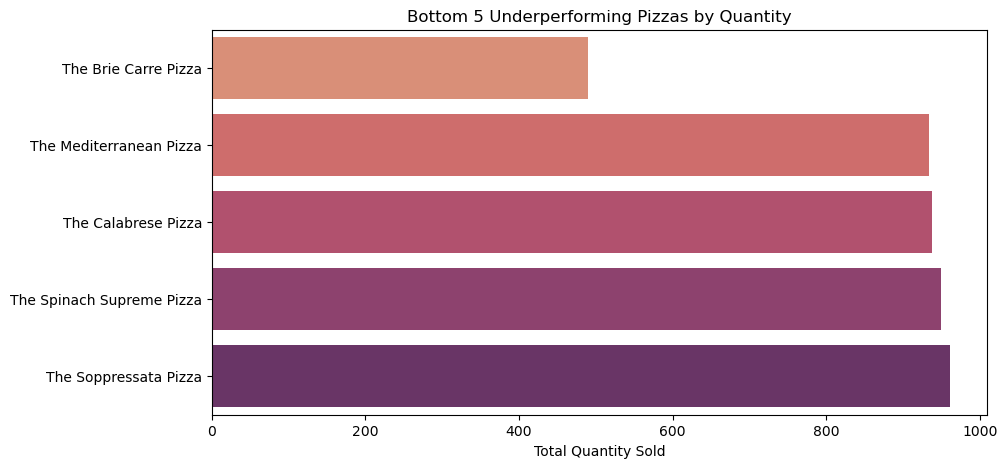

In [50]:
bottom_pizzas_df = bottom_pizzas.reset_index()
plt.figure(figsize=(10, 5))

#Barplot
sns.barplot(data=bottom_pizzas_df, y='name', x='quantity', palette='flare')
plt.title('Bottom 5 Underperforming Pizzas by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('')

plt.show()

### Insight:
Yes, there are underperforming items. The Brie Carre Pizza is doing exceptionally poorly compared to the rest of the menu, selling only 490 units the entire year. The Mediterranean and Calabrese pizzas are also lagging behind, selling under 1,000 units each.